In [1]:
import numpy as np
import os
import random
from PIL import Image, ImageEnhance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [2]:
train_dir = r"C:\Users\User\Downloads\braintumor\Training"
test_dir = r"C:\Users\User\Downloads\braintumor\Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

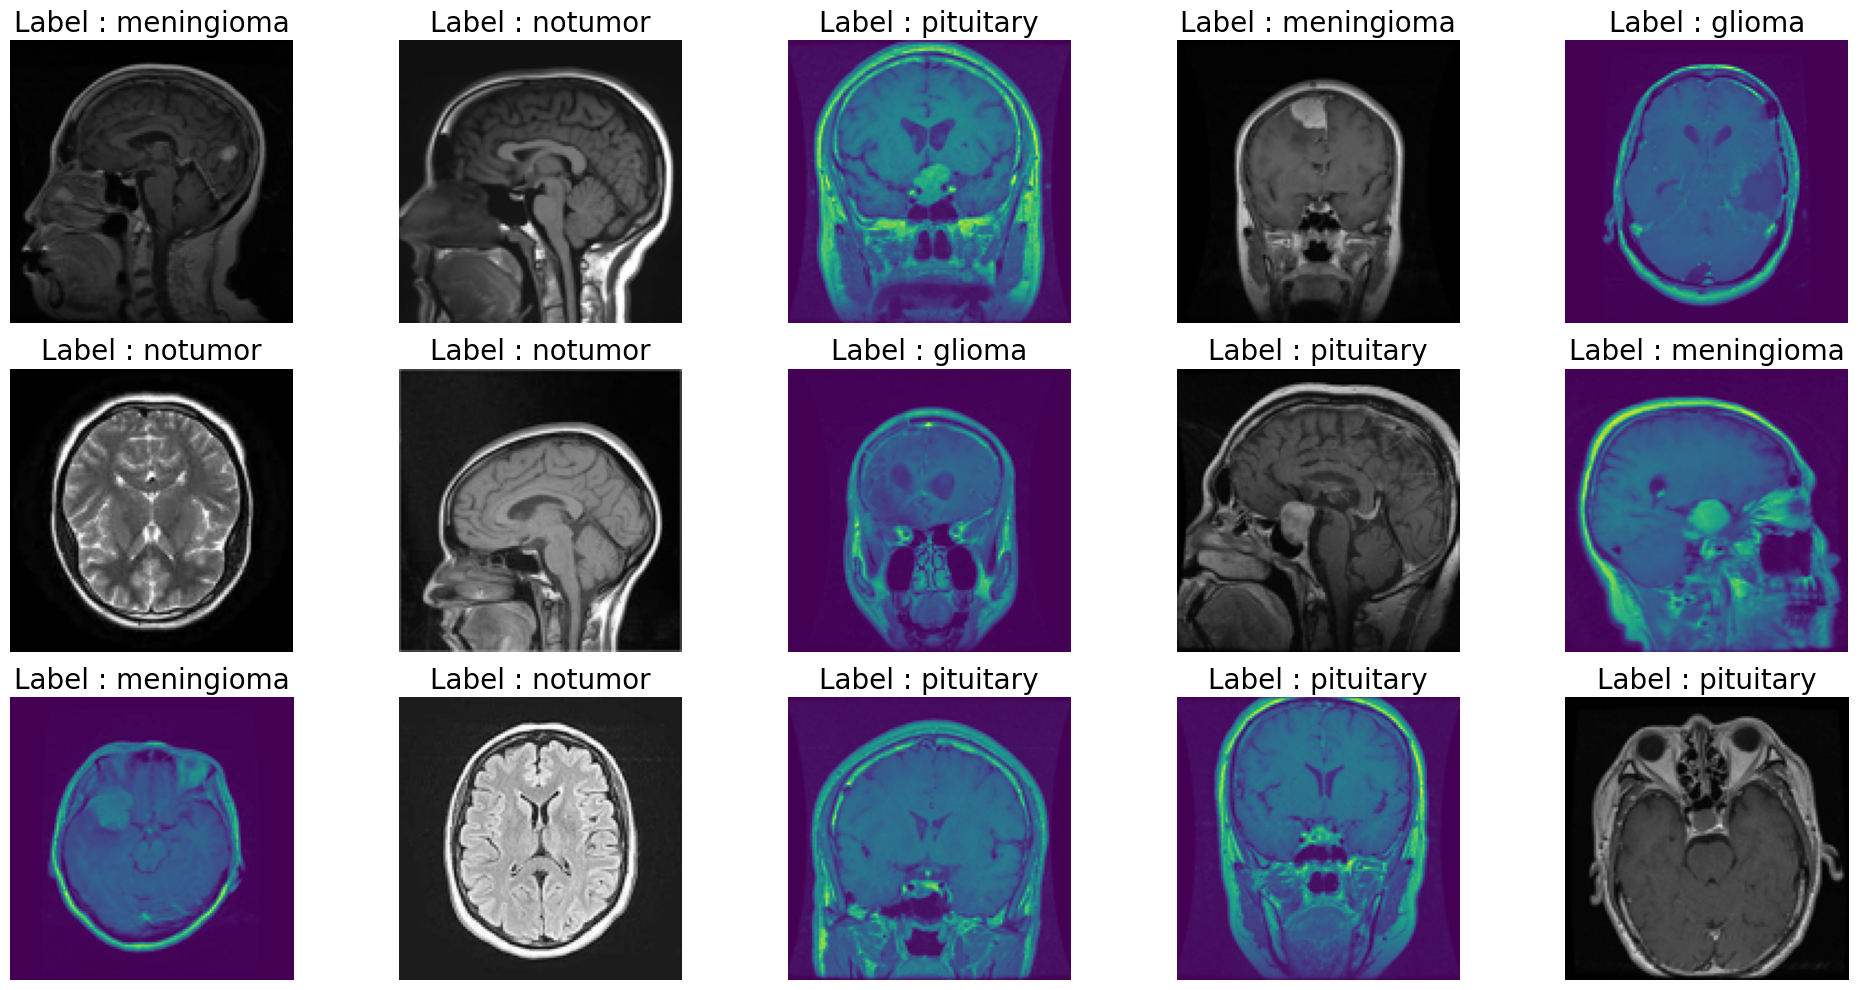

In [3]:
import random
import matplotlib.pyplot as plt

#select random indices for  images
random_indices = random.sample(range(len(train_paths)), 15)
random_indices

#create figure diplay img in 2r
fig, axes = plt.subplots(3, 5, figsize = (20, 10))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))
    axes[i].set_title(f'Label : {train_labels[idx]}', fontsize = 20)

    #display img
    axes[i].imshow(img)
    axes[i].axis('off')
plt.tight_layout()

In [4]:
# Image augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths :
        image = load_img(path, target_size= (IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)
        
def encode_labels(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size = 12, epochs = 1):
    for _ in range (epochs):
        for i in range (0, len(paths), batch_size):
            batch_paths = paths[i : i + batch_size]
            batch_images = open_images(batch_paths)# open and augment images
            batch_labels = labels[i : i + batch_size]
            batch_labels = encode_labels(batch_labels) #encode labels
            yield batch_images, batch_labels #yield the batch

In [6]:
IMAGE_SIZE = 64
base_model = VGG16(input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3), include_top = False, weights = 'imagenet')

for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape = (IMAGE_SIZE, IMAGE_SIZE, 3))) #input layer
model.add(base_model) #vgg16 layer
model.add(Flatten()) #FLATTEN layer
model.add(Dropout(0.3)) #dropout layer

          
model.add(Dense(128, activation = 'relu')) #dense layer
model.add(Dropout(0.2)) #dropout layer

model.add(Dense(len(os.listdir(train_dir)), activation = 'softmax')) #output layer

#compile model
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'sparse_categorical_crossentropy',
                                                         metrics = ['sparse_categorical_accuracy'])
#parameter
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

#train model
history = model.fit(
    datagen(train_paths, train_labels, batch_size = batch_size, epochs = epochs),
    epochs = epochs, steps_per_epoch = steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 99s 342ms/step - loss: 0.7770 - sparse_categorical_accuracy: 0.6887
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 85s 299ms/step - loss: 0.3445 - sparse_categorical_accuracy: 0.8673
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 84s 296ms/step - loss: 0.2451 - sparse_categorical_accuracy: 0.9065
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 85s 300ms/step - loss: 0.2186 - sparse_categorical_accuracy: 0.9132
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 85s 299ms/step - loss: 0.1946 - sparse_categorical_accuracy: 0.9252


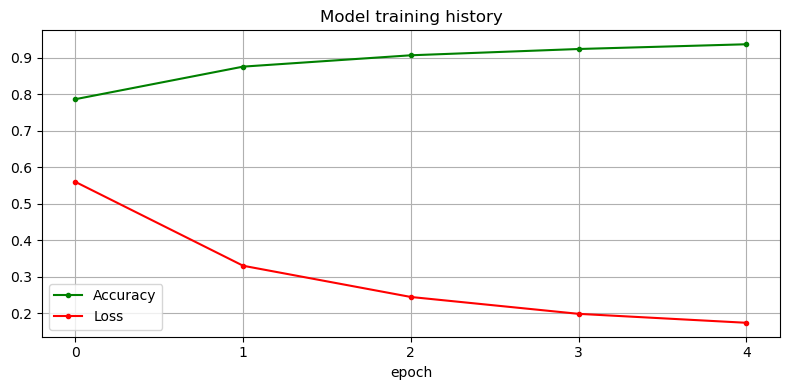

In [7]:
plt.figure(figsize = (8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth = 1.5)
plt.plot(history.history['loss'], '.r-', linewidth = 1.5)
plt.title('Model training history')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'])
plt.tight_layout()

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_labels(test_labels)

test_predictions = model.predict(test_images)

print('Classification Report')
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis = 1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 293ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       300
           1       0.94      0.48      0.64       306
           2       0.99      0.96      0.97       405
           3       0.82      0.99      0.89       300

    accuracy                           0.85      1311
   macro avg       0.86      0.84      0.83      1311
weighted avg       0.87      0.85      0.84      1311



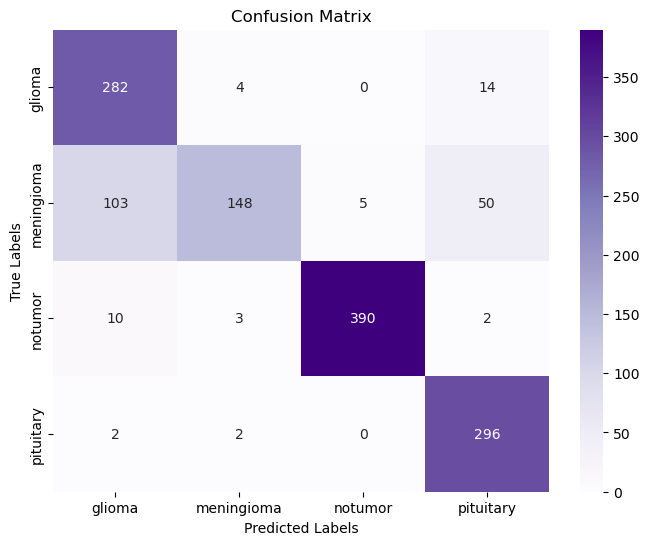

In [9]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

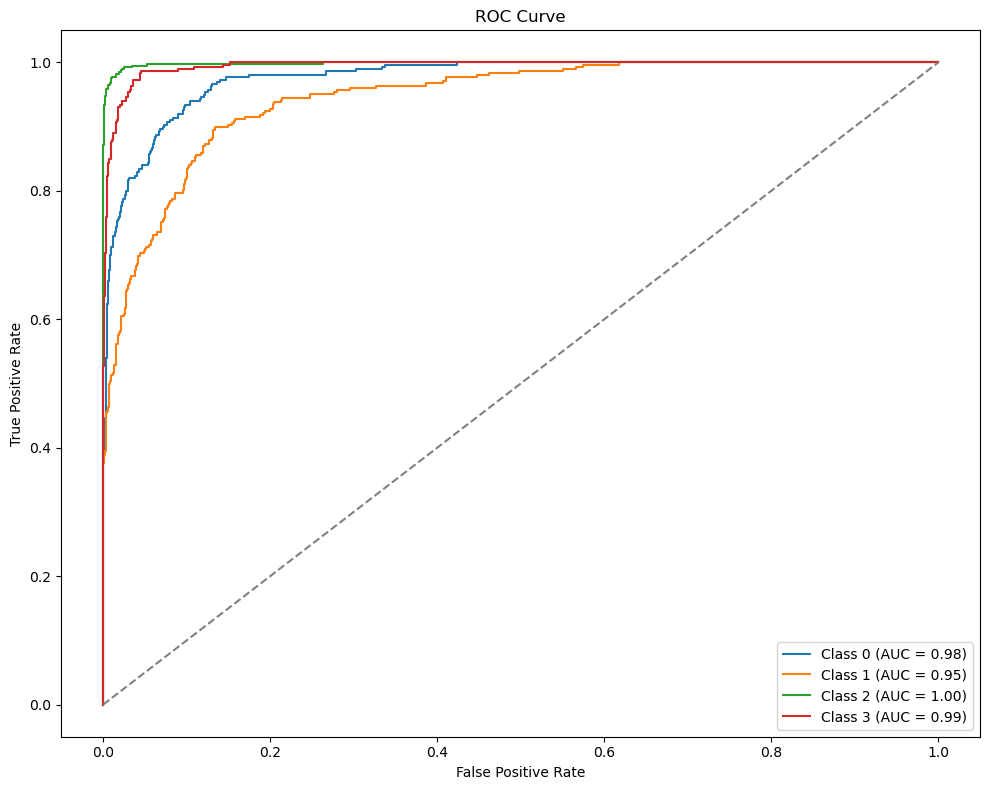

In [10]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

In [11]:
model.save(r"C:\Users\User\Downloads\braintumormodel.h5")
print("Model saved as braintumormodel.h5")

Model saved as braintumormodel.h5


In [12]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model(r"C:\Users\User\Downloads\braintumormodel.h5")